## 字符串传入模型

官方支持的模型可以直接传入字符串，注意env文件中配置密钥。

<class 'langgraph.graph.state.CompiledStateGraph'>


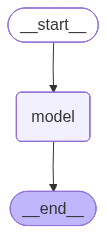

In [1]:
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv(override=True)
 
agent = create_agent("deepseek:deepseek-v4-flash") # 最好把供应商写上去

print(type(agent))

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
## 直接传入模型实例

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
import os
load_dotenv(override=True)

model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL")
)
agent = create_agent(model)
print(type(agent))
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## invoke调用

`agent.invoke()` 是Agent最基本的同步调用方法，它会阻塞程序执行直到返回最终结果。具体的：
- 输入：传入的参数为字典类型，字典内通过 `messages` 字段传递消息列表。即：`{"messages": [{"role": "...", "content": "..."}]}`
- 输出：通过invoke调用Agent，底层可能会经历多轮交互，返回的是完整的**消息列表**，被封装在字典中，是 `messages` 字段的值。

```python
response = agent.invoke({"messages": [...]})

# response 是字典类型
{
    "messages": [
        HumanMessage(...),    # 用户问题
        AIMessage(...),      # AI 工具调用
        ToolMessage(...),    # 工具返回结果
        AIMessage(...)       # 最终回答 ← 通常取这个
    ]
}

# 获取最终回答
final_answer = response['messages'][-1].content
```

In [1]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

load_dotenv(override=True)
from rich import print as rich_print

# 以init_chat_model为例
model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL")
)

agent = create_agent(model)

resp = agent.invoke({
    "messages": [
        {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
        {"role": "user", "content": "100加上50等于多少？"}
    ]
})

rich_print(resp)

{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='848f1948-5885-4daa-bb4b-740e59008897'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='c9da5220-96f7-40bb-9267-6a7fcfee0d8f'
        ),
        AIMessage(
            content='100 加上 50 等于 **150**。\n\n可以这样想：\n- 100 是一百\n- 再加 50，就是再多 5 个十\n- 
所以一共是 **150**\n\n如果你愿意，我还可以教你怎么用“数位”来快速算这类加法。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 72,
                    'prompt_tokens': 36,
                    'total_tokens': 108,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': None,
                        'image_tokens': 0
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cached_tokens': 0,
                        'cache_write_tokens': 0,
                        'video_tokens': 0
                    },
                    'cost': 0.000351,
                    'is_byok': False,
                    'cost_details': {
                        'upstream_inference_cost': 0.000351,
                        'upstream_inference_prompt_cost': 2.7e-05,
                        'upstream_inference_completions_cost': 0.000324
                    }
                },
                'model_provider': 'openai',
                'model_name': 'openai/gpt-5.4-mini',
                'system_fingerprint': None,
                'id': 'gen-1784109314-K8XOGbVP9QS2t3hVbnxq',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f6533-a8f4-71d0-91a1-1fd92c473165-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 36,
                'output_tokens': 72,
                'total_tokens': 108,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}